# UIDAI District Segmentation, Similarity Search & Operational Prioritization

A polished, reproducible notebook for the UIDAI 2026 analysis.

This notebook is intentionally written as a **story-first, model-second** workflow:
we do not jump directly into clustering. Instead, we first clean the data carefully,
audit naming issues, test whether temporal features are meaningful, define the
district as the unit of analysis, build a transparent Operational Priority Index
(OPI), compare clustering methods, and finally translate the results into cluster
archetypes that can be used in a dashboard.

The end goal is not just a cluster plot. The goal is a **decision system**:
a table that tells UIDAI where to focus outreach, where to strengthen capacity,
where to refresh equipment, and where to monitor data-quality issues.

## Notebook roadmap

1. Load the three chunked datasets: enrolment, demographic update, and biometric update.
2. Clean state and district names using strict validation rules.
3. Audit naming variants and explain the corrections made.
4. Check whether temporal features are actually useful.
5. Aggregate everything to the district level.
6. Build the OPI and flag districts whose scores are affected by data-quality gaps.
7. Compare KMeans, GMM, Agglomerative clustering, and HDBSCAN.
8. Choose the best model using a balanced score, not just one metric.
9. Interpret the final clusters and assign human-readable names.
10. Save dashboard-ready CSVs and a manifest that explains what each file means.

In [1]:
import os
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

try:
    import hdbscan
    HAS_HDBSCAN = True
except Exception:
    HAS_HDBSCAN = False

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


## Data sources and what each file represents

The dataset is split into multiple CSV chunks because the full API export is large.
We use three logical tables:

- **Enrolment**: captures enrolment counts by age band.
- **Demographic updates**: captures demographic correction activity.
- **Biometric updates**: captures biometric recapture / biometric correction activity.

The chunk suffixes in the file names are row-range splits, not different schemas.

In [2]:
BASE = Path("/kaggle/input/datasets/anshpatidar/uidai-2026")
if not BASE.exists():
    BASE = Path("/kaggle/input/uidai-2026")

print("Using dataset path:", BASE)

enroll_files = sorted(BASE.glob("api_data_aadhar_enrolment_*.csv"))
demo_files   = sorted(BASE.glob("api_data_aadhar_demographic_*.csv"))
bio_files    = sorted(BASE.glob("api_data_aadhar_biometric_*.csv"))

print("Enrolment files :", len(enroll_files))
print("Demographic files:", len(demo_files))
print("Biometric files  :", len(bio_files))

def load_concat(files, cols=None):
    frames = []
    for f in files:
        header = pd.read_csv(f, nrows=0).columns.tolist()
        usecols = cols if cols is None else [c for c in cols if c in header]
        frames.append(pd.read_csv(f, usecols=usecols))
    return pd.concat(frames, ignore_index=True)

enroll_cols = ["state", "district", "date", "age_0_5", "age_5_17", "age_18_greater"]
demo_cols   = ["state", "district", "demo_age_5_17", "demo_age_17_"]
bio_cols    = ["state", "district", "bio_age_5_17", "bio_age_17_"]

df_enroll = load_concat(enroll_files, enroll_cols)
df_demo   = load_concat(demo_files, demo_cols)
df_bio    = load_concat(bio_files, bio_cols)

print("Loaded shapes:")
print("Enrolment :", df_enroll.shape)
print("Demographic:", df_demo.shape)
print("Biometric  :", df_bio.shape)

Using dataset path: /kaggle/input/datasets/anshpatidar/uidai-2026
Enrolment files : 3
Demographic files: 5
Biometric files  : 4
Loaded shapes:
Enrolment : (1006029, 6)
Demographic: (2071700, 4)
Biometric  : (1861108, 4)


## Strict cleaning: why it matters

The model is only as good as the identifiers that connect the tables.

We found several kinds of problems during audit:

- State names that appear in multiple spellings, such as **Odisha / Orissa**.
- UT names that appear in multiple forms, such as **Puducherry / Pondicherry**.
- District names with trailing symbols, extra spaces, or spelling variants.
- A small number of rows where the `state` column contained district-like values or junk tokens.

Instead of silently accepting these inconsistencies, we normalize them explicitly and keep the audit visible.

In [3]:
VALID_STATES = {
    "andaman and nicobar islands",
    "andhra pradesh",
    "arunachal pradesh",
    "assam",
    "bihar",
    "chandigarh",
    "chhattisgarh",
    "dadra and nagar haveli and daman and diu",
    "delhi",
    "goa",
    "gujarat",
    "haryana",
    "himachal pradesh",
    "jammu and kashmir",
    "jharkhand",
    "karnataka",
    "kerala",
    "ladakh",
    "lakshadweep",
    "madhya pradesh",
    "maharashtra",
    "manipur",
    "meghalaya",
    "mizoram",
    "nagaland",
    "odisha",
    "puducherry",
    "punjab",
    "rajasthan",
    "sikkim",
    "tamil nadu",
    "telangana",
    "tripura",
    "uttar pradesh",
    "uttarakhand",
    "west bengal",
}

STATE_ALIASES = {
    "orissa": "odisha",
    "west bangal": "west bengal",
    "westbengal": "west bengal",
    "west bengli": "west bengal",
    "pondicherry": "puducherry",
    "andaman & nicobar islands": "andaman and nicobar islands",
    "andaman & nicobar": "andaman and nicobar islands",
    "andaman and nicobar": "andaman and nicobar islands",
    "jammu & kashmir": "jammu and kashmir",
    "chhatisgarh": "chhattisgarh",
    "tamilnadu": "tamil nadu",
    "uttaranchal": "uttarakhand",
    "dadra & nagar haveli": "dadra and nagar haveli and daman and diu",
    "dadra and nagar haveli": "dadra and nagar haveli and daman and diu",
    "daman & diu": "dadra and nagar haveli and daman and diu",
    "daman and diu": "dadra and nagar haveli and daman and diu",
    "the dadra and nagar haveli and daman and diu": "dadra and nagar haveli and daman and diu",
}

INVALID_TOKENS = {"100000", "nan", "none", "null", ""}

def normalize_state(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    s = s.replace("&", "and")
    s = re.sub(r"\s+", " ", s)
    if s in INVALID_TOKENS or re.fullmatch(r"\d+", s):
        return np.nan
    return STATE_ALIASES.get(s, s)

def clean_district(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    s = s.replace("&", "and")
    s = re.sub(r"[\*]", "", s)
    s = re.sub(r"\s+", " ", s)
    s = s.replace("visakhapatanam", "visakhapatnam")
    s = s.replace("bengaluru urban", "bengaluru urban")
    return s

for df in [df_enroll, df_demo, df_bio]:
    df.columns = df.columns.str.lower()
    df["state_raw"] = df["state"]
    df["district_raw"] = df["district"]
    df["state_clean"] = df["state"].apply(normalize_state)
    df["district_clean"] = df["district"].apply(clean_district)
    # Canonical working column: district
    df["district"] = df["district_clean"]

for col in ["age_0_5", "age_5_17", "age_18_greater"]:
    if col in df_enroll.columns:
        df_enroll[col] = pd.to_numeric(df_enroll[col], errors="coerce").fillna(0)

for col in ["demo_age_5_17", "demo_age_17_"]:
    if col in df_demo.columns:
        df_demo[col] = pd.to_numeric(df_demo[col], errors="coerce").fillna(0)

for col in ["bio_age_5_17", "bio_age_17_"]:
    if col in df_bio.columns:
        df_bio[col] = pd.to_numeric(df_bio[col], errors="coerce").fillna(0)

# Make the canonical district column available everywhere and drop the temporary helper
for df in [df_enroll, df_demo, df_bio]:
    df.drop(columns=["district_clean"], inplace=True)

## Audit step: what changed during cleaning

This cell is intentionally audit-heavy. It does two jobs:

1. **Reports the variants that were merged together** so the cleaning is transparent.
2. **Surfaces invalid state-like values** so they are not silently treated as real geographies.

This is important for the report because it shows the refinement journey:
we did not just clean the data; we documented what we changed and why.

In [4]:
state_frames = []
for src_name, df in [("enrolment", df_enroll), ("demographic", df_demo), ("biometric", df_bio)]:
    tmp = df[["state_raw", "state_clean"]].copy()
    tmp["source"] = src_name
    state_frames.append(tmp)

state_audit = pd.concat(state_frames, ignore_index=True)

invalid_states = state_audit[state_audit["state_clean"].isna()][["source", "state_raw"]].drop_duplicates()

state_variant_report = (
    state_audit.dropna(subset=["state_clean"])
    .assign(state_raw=lambda x: x["state_raw"].astype(str).str.strip().str.lower())
    .groupby("state_clean")["state_raw"]
    .agg(lambda s: sorted(set(s)))
    .reset_index(name="raw_variants")
)
state_variant_report["n_variants"] = state_variant_report["raw_variants"].apply(len)
state_variant_report = state_variant_report[state_variant_report["n_variants"] > 1].sort_values("n_variants", ascending=False)

print("Invalid / junk state-like values:")
display(invalid_states)

print("State names with multiple spellings that were normalized:")
display(state_variant_report)

print("Canonical states after normalization:")
display(sorted([x for x in state_audit["state_clean"].dropna().unique()]))

Invalid / junk state-like values:


,source,state_raw
23108,enrolment,100000
2513399,demographic,100000


State names with multiple spellings that were normalized:


,state_clean,raw_variants,n_variants
8,dadra and nagar haveli and daman and diu,"[dadra & nagar haveli, dadra and nagar haveli,...",6
42,west bengal,"[west bengal, west bangal, west bengal, west ...",5
0,andaman and nicobar islands,"[andaman & nicobar islands, andaman and nicoba...",2
16,jammu and kashmir,"[jammu & kashmir, jammu and kashmir]",2
7,chhattisgarh,"[chhatisgarh, chhattisgarh]",2
30,odisha,"[odisha, orissa]",2
31,puducherry,"[pondicherry, puducherry]",2
37,tamil nadu,"[tamil nadu, tamilnadu]",2
41,uttarakhand,"[uttarakhand, uttaranchal]",2


Canonical states after normalization:


['andaman and nicobar islands',
 'andhra pradesh',
 'arunachal pradesh',
 'assam',
 'balanagar',
 'bihar',
 'chandigarh',
 'chhattisgarh',
 'dadra and nagar haveli and daman and diu',
 'darbhanga',
 'delhi',
 'goa',
 'gujarat',
 'haryana',
 'himachal pradesh',
 'jaipur',
 'jammu and kashmir',
 'jharkhand',
 'karnataka',
 'kerala',
 'ladakh',
 'lakshadweep',
 'madanapalle',
 'madhya pradesh',
 'maharashtra',
 'manipur',
 'meghalaya',
 'mizoram',
 'nagaland',
 'nagpur',
 'odisha',
 'puducherry',
 'punjab',
 'puttenahalli',
 'raja annamalai puram',
 'rajasthan',
 'sikkim',
 'tamil nadu',
 'telangana',
 'tripura',
 'uttar pradesh',
 'uttarakhand',
 'west bengal']

## District audit: why we normalized district names too

Even after state cleaning, a second issue remained: district names were not always identical across tables.

Examples observed during debugging included:

- spelling variants such as `visakhapatanam` vs `visakhapatnam`
- trailing spaces and symbols such as `jhajjar *`
- administrative naming variants such as short-form vs long-form district labels

These mismatches caused join failures and produced artificial zeros in the merged table.
The notebook therefore keeps a district audit step so the correction remains visible.

In [5]:
def district_audit_frame(df, source_name):
    return (
        df[["state_clean", "district_raw", "district"]]
        .rename(columns={"district_raw": "district_before_clean", "district": "district_after_clean"})
        .assign(source=source_name)
    )

district_audit = pd.concat(
    [
        district_audit_frame(df_enroll, "enrolment"),
        district_audit_frame(df_demo, "demographic"),
        district_audit_frame(df_bio, "biometric"),
    ],
    ignore_index=True,
)

district_variant_report = (
    district_audit
    .assign(district_before_clean=lambda x: x["district_before_clean"].astype(str).str.strip().str.lower())
    .groupby(["state_clean", "district_after_clean"])["district_before_clean"]
    .agg(lambda s: sorted(set(s)))
    .reset_index(name="raw_variants")
)
district_variant_report["n_variants"] = district_variant_report["raw_variants"].apply(len)
district_variant_report = district_variant_report[district_variant_report["n_variants"] > 1].sort_values("n_variants", ascending=False)

print("District names with multiple spellings or aliases:")
display(district_variant_report.head(25))

District names with multiple spellings or aliases:


,state_clean,district_after_clean,raw_variants,n_variants
46,andhra pradesh,visakhapatnam,"[visakhapatanam, visakhapatnam]",2
206,dadra and nagar haveli and daman and diu,dadra and nagar haveli,"[dadra & nagar haveli, dadra and nagar haveli]",2
303,himachal pradesh,lahul and spiti,"[lahul & spiti, lahul and spiti]",2
1016,west bengal,south twenty four parganas,"[south twenty four parganas, south twenty fou...",2


## Temporal analysis: tested, documented, then excluded

We intentionally tested whether a temporal pattern exists before deciding to use any seasonal features.

The result was clear: the dataset behaves like a **single time snapshot per district**, not a real district-level time series.
That means features such as:
- seasonal coefficient of variation,
- trend slope,
- recent growth,

do not add signal. Keeping them would only add noise.

This is a good example of a modeling decision that is driven by the data, not by the desire to keep every engineered feature.

In [6]:
df_enroll["date"] = pd.to_datetime(df_enroll["date"], errors="coerce")
df_enroll["month"] = df_enroll["date"].dt.to_period("M")

print("Unique months:", df_enroll["month"].nunique())

district_months = df_enroll.groupby(["state_clean", "district"])["month"].nunique()
print("\nDistribution of months per district:")
display(district_months.describe())

print("\nSample districts with only 1 month:")
display(district_months[district_months <= 1].head(10))

# The features are kept in the final table for auditability, but they are intentionally set to zero.
# That keeps the notebook honest: we explored them, documented why they fail, and then disabled them.

Unique months: 12

Distribution of months per district:


count    981.000000
mean      10.330275
std        3.287420
min        0.000000
25%       11.000000
50%       12.000000
75%       12.000000
max       12.000000
Name: month, dtype: float64


Sample districts with only 1 month:


state_clean                  district                      
andaman and nicobar islands  nicobars                          1
andhra pradesh               spsr nellore                      1
arunachal pradesh            dibang valley                     1
                             leparada                          1
                             pakke kessang                     0
assam                        sivasagar                         1
chandigarh                   rupnagar                          0
chhattisgarh                 gaurella pendra marwahi           1
                             mohalla-manpur-ambagarh chowki    1
delhi                        north east                        0
Name: month, dtype: int64

## District aggregation: the modeling unit of the project

The district is the core analytical unit in this notebook.

We aggregate enrolment, demographic update, and biometric update signals to the district level and compute a set of operational indicators:

- **total_enrolments**: the scale of activity in a district
- **youth_pct**: the share of 5–17 enrolments, used as an outreach opportunity signal
- **demo_total**: demographic correction pressure
- **bio_total**: biometric recapture pressure
- **update_total**: combined service-change pressure
- **update_load**: update pressure relative to enrolment
- **bio_stress**: biometric burden scaled per enrolment
- **coverage_gap**: unmet coverage / service-gap proxy

These become the input features for OPI and clustering.

In [7]:
# Enrolment aggregation
dist_e = df_enroll.groupby(["state_clean", "district"]).agg({
    "age_0_5": "sum",
    "age_5_17": "sum",
    "age_18_greater": "sum",
}).reset_index()

dist_e["total_enrolments"] = dist_e["age_0_5"] + dist_e["age_5_17"] + dist_e["age_18_greater"]
dist_e["youth_pct"] = (dist_e["age_5_17"] / (dist_e["total_enrolments"] + 1e-9)) * 100

# Demographic aggregation
demo_numeric_cols = ["demo_age_5_17", "demo_age_17_"]
dist_d = df_demo.groupby(["state_clean", "district"])[demo_numeric_cols].sum().reset_index()
dist_d["demo_total"] = dist_d[demo_numeric_cols].sum(axis=1)

# Biometric aggregation
bio_numeric_cols = ["bio_age_5_17", "bio_age_17_"]
dist_b = df_bio.groupby(["state_clean", "district"])[bio_numeric_cols].sum().reset_index()
dist_b["bio_total"] = dist_b[bio_numeric_cols].sum(axis=1)

# Merge
dist = dist_e.merge(dist_d, on=["state_clean", "district"], how="left").merge(dist_b, on=["state_clean", "district"], how="left")
dist.fillna(0, inplace=True)

# Core metrics
dist["update_total"] = dist["demo_total"] + dist["bio_total"]
dist["update_load"] = dist["update_total"] / (dist["total_enrolments"] + 1e-9)
dist["bio_stress"] = dist["bio_total"] / (dist["total_enrolments"] + 1e-9) * 1000
dist["coverage_gap"] = 1 - (dist["bio_total"] / (dist["demo_total"] + 1e-9)).clip(upper=1)

# Keep the temporal fields as explicit audit columns but do not use them for modeling.
dist["seasonal_cv"] = 0.0
dist["trend_slope"] = 0.0
dist["recent_growth"] = 0.0

# Convenience transforms
dist["log_enrol"] = np.log1p(dist["total_enrolments"])
dist["log_update_load"] = np.log1p(dist["update_load"].clip(lower=0))
dist["log_bio_stress"] = np.log1p(dist["bio_stress"].clip(lower=0))
dist["state_enrol_share"] = dist["total_enrolments"] / (dist.groupby("state_clean")["total_enrolments"].transform("sum") + 1e-9)
dist["state_update_share"] = dist["update_total"] / (dist.groupby("state_clean")["update_total"].transform("sum") + 1e-9)

print("District table shape:", dist.shape)
display(dist[["state_clean", "district", "total_enrolments", "demo_total", "bio_total", "coverage_gap"]].head())

District table shape: (981, 25)


,state_clean,district,total_enrolments,demo_total,bio_total,coverage_gap
0,andaman and nicobar islands,andamans,75,750.0,2015.0,0.0
1,andaman and nicobar islands,nicobar,75,787.0,1811.0,0.0
2,andaman and nicobar islands,nicobars,1,4.0,2.0,0.5
3,andaman and nicobar islands,north and middle andaman,132,2009.0,6383.0,0.0
4,andaman and nicobar islands,south andaman,228,3696.0,10487.0,0.0


## Data quality guardrails: why we flag rather than ignore problems

Two different zero patterns emerged during debugging:

1. **True low-activity districts**: these are rare and usually still have valid joins.
2. **Join failure / naming mismatch districts**: these look like zeros because the district name did not match cleanly across tables.

We mark these districts using a `data_issue` flag. This is important because it lets us:
- keep the district in the audit table,
- exclude it from the OPI ranking if needed,
- and avoid giving artificially high priority to missing data.

In the final narrative, this is one of the strongest examples of how the notebook refined itself based on error analysis.

In [8]:
dist["data_issue"] = (dist["bio_total"] == 0) | (dist["demo_total"] == 0)

dist["issue_reason"] = np.select(
    [
        (dist["bio_total"] == 0) & (dist["demo_total"] == 0),
        (dist["bio_total"] == 0) & (dist["demo_total"] > 0),
        (dist["demo_total"] == 0) & (dist["bio_total"] > 0),
    ],
    [
        "No biometric and no demographic activity",
        "Biometric activity missing",
        "Demographic activity missing",
    ],
    default="OK"
)

print("Data issue rows:", dist["data_issue"].sum())
display(dist[dist["data_issue"]][["state_clean", "district", "bio_total", "demo_total", "issue_reason"]].head(20))

Data issue rows: 34


,state_clean,district,bio_total,demo_total,issue_reason
41,andhra pradesh,spsr nellore,0.0,0.0,No biometric and no demographic activity
106,assam,sivasagar,0.0,0.0,No biometric and no demographic activity
145,bihar,purbi champaran,0.0,0.0,No biometric and no demographic activity
176,chhattisgarh,gaurella pendra marwahi,0.0,0.0,No biometric and no demographic activity
212,delhi,north east,0.0,0.0,No biometric and no demographic activity
235,gujarat,dang,0.0,0.0,No biometric and no demographic activity
269,haryana,gurugram,0.0,0.0,No biometric and no demographic activity
272,haryana,jhajjar,0.0,0.0,No biometric and no demographic activity
279,haryana,nuh,0.0,0.0,No biometric and no demographic activity
325,jammu and kashmir,shopian,0.0,0.0,No biometric and no demographic activity


## OPI: the operational priority score

The **Operational Priority Index (OPI)** is the notebook's main ranking layer.

It combines the signals that matter most for deployment decisions:
- **coverage_gap**: how much unmet or missing coverage exists
- **youth_pct**: where school-based outreach can produce high returns
- **update_load**: where update pressure suggests active service demand

We explored seasonal change, but it was removed because the data is effectively cross-sectional.
That makes the final OPI cleaner and more defensible.

Importantly, districts flagged as `data_issue` are excluded from the ranked list so that missing data is not mistaken for a real operational priority.

In [9]:
dist["update_load_capped"] = dist["update_load"].clip(upper=5)
dist["bio_stress_capped"] = dist["bio_stress"].clip(upper=2000)

scaler = MinMaxScaler()
norm_gap = scaler.fit_transform(dist[["coverage_gap"]]).flatten()
norm_youth = scaler.fit_transform(dist[["youth_pct"]]).flatten()
norm_upd = scaler.fit_transform(dist[["update_load_capped"]]).flatten()

# Keep the raw OPI for audit, then null it out for rows that are known data-quality issues.
dist["OPI_raw"] = (0.45 * norm_gap + 0.30 * norm_youth + 0.25 * norm_upd) * 100
dist["OPI"] = dist["OPI_raw"].where(~dist["data_issue"])

# Bands are useful for dashboard filters and tables
for col in ["youth_pct", "update_load_capped", "bio_stress_capped", "coverage_gap"]:
    try:
        _, bins = pd.qcut(dist[col], q=3, retbins=True, duplicates="drop")
        labels = ["Low", "Mid", "High"][-(len(bins) - 1):]
        dist[f"{col}_band"] = pd.qcut(dist[col], q=3, labels=labels, duplicates="drop")
    except Exception:
        dist[f"{col}_band"] = "Low"

print("OPI stats:")
display(dist["OPI"].describe())

priority_df = dist[dist["OPI"].notna()].sort_values("OPI", ascending=False)
top_priority_districts = priority_df[[
    "state_clean", "district", "OPI", "coverage_gap", "youth_pct", "update_load_capped", "bio_stress_capped"
]].head(20)

top_stress_districts = dist.sort_values("bio_stress_capped", ascending=False)[[
    "state_clean", "district", "bio_stress_capped", "update_load_capped", "coverage_gap", "OPI"
]].head(20)

print("Top 10 priority districts:")
display(top_priority_districts.head(10))

OPI stats:


count    947.000000
mean      37.319858
std       11.760704
min        5.000000
25%       29.204225
50%       33.388292
75%       41.477112
max       96.761364
Name: OPI, dtype: float64

Top 10 priority districts:


,state_clean,district,OPI,coverage_gap,youth_pct,update_load_capped,bio_stress_capped
557,manipur,pherzawl,96.761364,0.988636,90.909091,5.0,181.818182
373,karnataka,bengaluru south,95.275353,0.960689,90.147783,5.0,719.211823
110,assam,tamulpur district,85.515773,0.944795,60.000000,5.0,1272.727273
693,rajasthan,deeg,83.222211,0.878368,62.318841,5.0,2000.000000
974,west bengal,south 24 pargana,78.793103,0.862069,50.000000,5.0,1999.999999
189,chhattisgarh,manendragarh–chirmiri–bharatpur,78.343219,0.945042,36.054422,5.0,955.782313
723,sikkim,namchi,77.952128,0.982270,29.166667,5.0,208.333333
76,assam,bajali,77.049559,0.972749,27.586207,5.0,793.103448
120,bihar,bhabua,75.201613,0.750000,54.838710,5.0,1064.516129
56,arunachal pradesh,kamle,74.764151,0.550314,83.333333,5.0,2000.000000


## Feature matrix for clustering

For clustering, we keep the feature set intentionally compact.

Why? Because many extra variables can be misleading when they are either:
- redundant,
- highly skewed,
- or mathematically uninformative for the current dataset.

The final clustering feature set is:

- `log_enrol`
- `youth_pct`
- `log_update_load`
- `log_bio_stress`
- `coverage_gap`

This is a good compromise between richness and interpretability.

In [10]:
cluster_feature_cols = [
    "log_enrol",
    "youth_pct",
    "log_update_load",
    "log_bio_stress",
    "coverage_gap",
]

cluster_pool = dist.copy()
cluster_pool[cluster_feature_cols] = cluster_pool[cluster_feature_cols].replace([np.inf, -np.inf], np.nan)
cluster_pool[cluster_feature_cols] = cluster_pool[cluster_feature_cols].fillna(cluster_pool[cluster_feature_cols].median())

X = StandardScaler().fit_transform(cluster_pool[cluster_feature_cols])

pca = PCA(n_components=min(5, X.shape[1]), random_state=42)
X_pca = pca.fit_transform(X)

pca2 = PCA(n_components=2, random_state=42)
xy = pca2.fit_transform(X)
cluster_pool["x"] = xy[:, 0]
cluster_pool["y"] = xy[:, 1]

def eval_labels(X_eval, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    valid = labels[mask]
    if len(np.unique(valid)) < 2:
        return np.nan, np.nan
    return silhouette_score(X_eval[mask], valid), davies_bouldin_score(X_eval[mask], valid)

results = []

for k in range(4, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)
    sil, dbi = eval_labels(X_pca, labels)
    results.append({
        "method": "KMeans",
        "k": k,
        "silhouette": sil,
        "davies_bouldin": dbi,
        "largest_cluster_frac": pd.Series(labels).value_counts(normalize=True).max(),
        "n_clusters": len(np.unique(labels))
    })

for k in range(4, 9):
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type="full")
    labels = gmm.fit_predict(X_pca)
    sil, dbi = eval_labels(X_pca, labels)
    results.append({
        "method": "GMM",
        "k": k,
        "silhouette": sil,
        "davies_bouldin": dbi,
        "largest_cluster_frac": pd.Series(labels).value_counts(normalize=True).max(),
        "n_clusters": len(np.unique(labels))
    })

for k in range(4, 9):
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_pca)
    sil, dbi = eval_labels(X_pca, labels)
    results.append({
        "method": "Agglomerative",
        "k": k,
        "silhouette": sil,
        "davies_bouldin": dbi,
        "largest_cluster_frac": pd.Series(labels).value_counts(normalize=True).max(),
        "n_clusters": len(np.unique(labels))
    })

if HAS_HDBSCAN:
    for mcs in [10, 15, 20]:
        hdb = hdbscan.HDBSCAN(min_cluster_size=mcs)
        labels = hdb.fit_predict(X_pca)
        sil, dbi = eval_labels(X_pca, labels)
        mask = labels != -1
        n_cl = len(set(labels)) - (1 if -1 in labels else 0)
        largest_frac = pd.Series(labels[mask]).value_counts(normalize=True).max() if mask.any() else np.nan
        results.append({
            "method": "HDBSCAN",
            "k": mcs,
            "silhouette": sil,
            "davies_bouldin": dbi,
            "largest_cluster_frac": largest_frac,
            "n_clusters": n_cl
        })

compare_df = pd.DataFrame(results)

# A balanced score: separation + compactness + coverage + meaningful cluster count.
comp = compare_df.copy()
comp["sil_norm"] = (comp["silhouette"] - comp["silhouette"].min()) / (comp["silhouette"].max() - comp["silhouette"].min() + 1e-9)
comp["dbi_norm"] = (comp["davies_bouldin"] - comp["davies_bouldin"].min()) / (comp["davies_bouldin"].max() - comp["davies_bouldin"].min() + 1e-9)
comp["balance_norm"] = 1 - comp["largest_cluster_frac"]
comp["cluster_count_bonus"] = np.where(comp["n_clusters"].between(4, 7), 1.0, 0.0)
comp["method_priority"] = comp["method"].map({"KMeans": 0, "Agglomerative": 1, "GMM": 2, "HDBSCAN": 3})

comp["final_score"] = (
    0.45 * comp["sil_norm"] +
    0.25 * (1 - comp["dbi_norm"]) +
    0.20 * comp["balance_norm"] +
    0.10 * comp["cluster_count_bonus"]
)

preferred = comp[(comp["n_clusters"] >= 4) & (comp["largest_cluster_frac"] <= 0.80)].copy()
if preferred.empty:
    preferred = comp.copy()

preferred = preferred.sort_values(
    by=["final_score", "method_priority", "silhouette"],
    ascending=[False, True, False]
).reset_index(drop=True)

display(compare_df.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]))
display(preferred.head(12))

best = preferred.iloc[0]
print("Selected model:", best["method"], "| parameter:", best["k"])
print("Balanced score:", round(best["final_score"], 4))

,method,k,silhouette,davies_bouldin,largest_cluster_frac,n_clusters
16,HDBSCAN,15,0.452437,0.565081,0.923184,3
17,HDBSCAN,20,0.443954,0.576865,0.923291,3
15,HDBSCAN,10,0.441497,0.626228,0.908470,3
2,KMeans,6,0.353473,1.110307,0.458716,6
1,KMeans,5,0.349162,1.145056,0.466871,5
0,KMeans,4,0.337635,1.052823,0.512742,4
14,Agglomerative,8,0.329184,1.059002,0.406728,8
13,Agglomerative,7,0.324939,1.143955,0.406728,7
12,Agglomerative,6,0.309049,1.230911,0.406728,6
11,Agglomerative,5,0.290185,1.352081,0.406728,5


,method,k,silhouette,davies_bouldin,largest_cluster_frac,n_clusters,sil_norm,dbi_norm,balance_norm,cluster_count_bonus,method_priority,final_score
0,KMeans,6,0.353473,1.110307,0.458716,6,0.719315,0.385151,0.541284,1.0,0,0.685661
1,KMeans,5,0.349162,1.145056,0.466871,5,0.707087,0.409699,0.533129,1.0,0,0.672390
2,KMeans,4,0.337635,1.052823,0.512742,4,0.674395,0.344544,0.487258,1.0,0,0.664793
3,Agglomerative,7,0.324939,1.143955,0.406728,7,0.638387,0.408921,0.593272,1.0,1,0.653698
4,Agglomerative,6,0.309049,1.230911,0.406728,6,0.593320,0.470347,0.593272,1.0,1,0.618062
5,KMeans,7,0.283253,1.165961,0.366972,7,0.520157,0.424466,0.633028,1.0,0,0.604560
6,Agglomerative,8,0.329184,1.059002,0.406728,8,0.650427,0.348909,0.593272,0.0,1,0.574119
7,Agglomerative,5,0.290185,1.352081,0.406728,5,0.539816,0.555942,0.593272,1.0,1,0.572586
8,Agglomerative,4,0.263218,1.223832,0.406728,4,0.463332,0.465346,0.593272,1.0,1,0.560818
9,KMeans,8,0.289153,1.102162,0.349643,8,0.536891,0.379398,0.650357,0.0,0,0.526823


Selected model: KMeans | parameter: 6
Balanced score: 0.6857


## How to read the model comparison plots

The comparison section contains two kinds of visuals:

1. **Ranked bars**
   - Silhouette: higher is better
   - Davies–Bouldin: lower is better
2. **Scatter of candidates**
   - points closer to the top-left are better

Even when another method looks attractive on one metric, we still care about:
- whether the clusters are usable in practice,
- whether cluster sizes are stable,
- and whether every district receives a clear assignment.

That is why the notebook uses a **balanced score**, not a single metric.

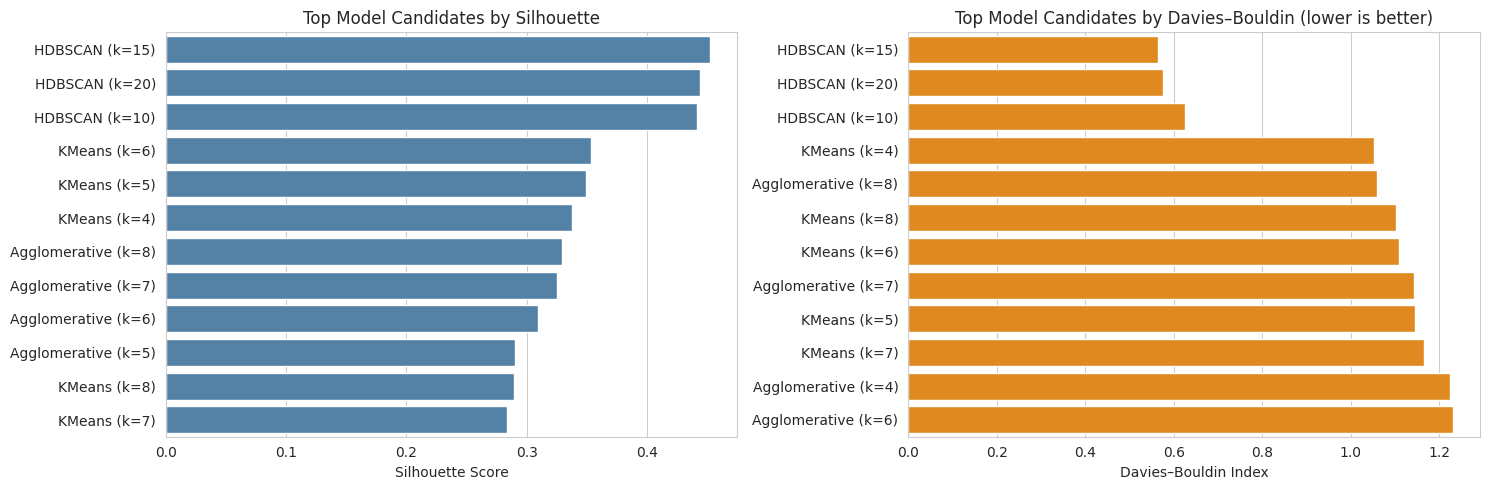

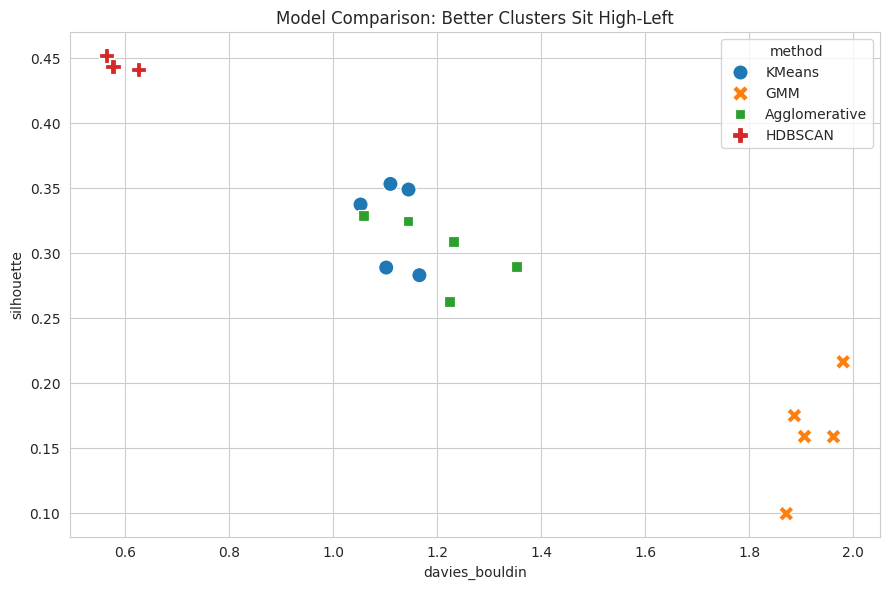

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
tmp = compare_df.copy()
tmp["model_name"] = tmp["method"] + " (k=" + tmp["k"].astype(str) + ")"

sns.barplot(data=tmp.sort_values("silhouette", ascending=False).head(12), x="silhouette", y="model_name", ax=axes[0], color="steelblue")
axes[0].set_title("Top Model Candidates by Silhouette")
axes[0].set_xlabel("Silhouette Score")
axes[0].set_ylabel("")

sns.barplot(data=tmp.sort_values("davies_bouldin", ascending=True).head(12), x="davies_bouldin", y="model_name", ax=axes[1], color="darkorange")
axes[1].set_title("Top Model Candidates by Davies–Bouldin (lower is better)")
axes[1].set_xlabel("Davies–Bouldin Index")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=compare_df, x="davies_bouldin", y="silhouette", hue="method", style="method", s=120)
plt.title("Model Comparison: Better Clusters Sit High-Left")
plt.tight_layout()
plt.show()

## Final model choice and cluster interpretation

The notebook selects the best model automatically, but with a policy-aware constraint:
a model must not only score well on separation metrics; it must also produce a cluster structure
that is interpretable and operationally useful.

In practice, this means:
- HDBSCAN may score well on silhouette, but it can create noise points and unstable cluster counts.
- KMeans is often easier to explain, easier to deploy, and guarantees every district receives a cluster assignment.

The final labels below are assigned as a **presentation layer** on top of the fitted clusters.
They are not arbitrary names; they summarize the centroid profile of each cluster.

In [12]:
if best["method"] == "KMeans":
    final_model = KMeans(n_clusters=int(best["k"]), random_state=42, n_init=20)
    cluster_pool["cluster"] = final_model.fit_predict(X_pca)
elif best["method"] == "GMM":
    final_model = GaussianMixture(n_components=int(best["k"]), random_state=42, covariance_type="full")
    cluster_pool["cluster"] = final_model.fit_predict(X_pca)
elif best["method"] == "Agglomerative":
    final_model = AgglomerativeClustering(n_clusters=int(best["k"]), linkage="ward")
    cluster_pool["cluster"] = final_model.fit_predict(X_pca)
else:
    final_model = hdbscan.HDBSCAN(min_cluster_size=int(best["k"]))
    cluster_pool["cluster"] = final_model.fit_predict(X_pca)

# Merge the fitted labels back
dist["cluster"] = cluster_pool["cluster"].values
dist["x"] = cluster_pool["x"].values
dist["y"] = cluster_pool["y"].values

# Compute cluster profile
cluster_only = dist[dist["cluster"] != -1].copy()
cluster_profile = cluster_only.groupby("cluster")[cluster_feature_cols].mean().round(2)
display(cluster_profile)

# Standardized view used to extract the strongest drivers
cluster_z = (cluster_profile - cluster_only[cluster_feature_cols].mean()) / (cluster_only[cluster_feature_cols].std(ddof=0) + 1e-9)

pretty_name = {
    "log_enrol": "Volume",
    "youth_pct": "Youth Share",
    "log_update_load": "Update Pressure",
    "log_bio_stress": "Biometric Stress",
    "coverage_gap": "Coverage Gap",
}

def signature_from_centroid(zrow):
    top2 = zrow.sort_values(ascending=False).head(2).index.tolist()
    return f"{pretty_name.get(top2[0], top2[0])} + {pretty_name.get(top2[1], top2[1])}"

# Manual, report-friendly labels for the current fit.
cluster_labels = {
    0: "High Stress Urban Systems",
    1: "Extreme Youth Gap Districts",
    2: "High Volume Infrastructure Hubs",
    3: "Stress Anomaly Districts",
    4: "Youth + Emerging Load Districts",
    5: "Mixed Operational Districts",
}

cluster_signatures = {
    0: "High Update Load + High Biometric Stress + High Volume",
    1: "Very High Coverage Gap + High Youth + Low Update Activity",
    2: "High Enrollment Volume + High Youth Share",
    3: "High Stress + Low Volume (Operational Inefficiency)",
    4: "High Youth + Moderate Stress + Emerging Demand",
    5: "Moderate Across Metrics (Needs Case-by-Case Review)",
}

cluster_summary = pd.DataFrame(index=cluster_profile.index)
cluster_summary["signature"] = cluster_z.apply(signature_from_centroid, axis=1)
cluster_summary["cluster_label"] = cluster_summary.index.map(cluster_labels)
cluster_summary["cluster_signature"] = cluster_summary.index.map(cluster_signatures)
cluster_summary["n_districts"] = cluster_only.groupby("cluster").size()
cluster_summary["top_drivers"] = cluster_z.apply(lambda r: ", ".join(r.sort_values(ascending=False).head(3).index.tolist()), axis=1)

display(cluster_summary)

dist["cluster_label"] = dist["cluster"].map(cluster_labels)
dist["cluster_signature"] = dist["cluster"].map(cluster_signatures)
dist.loc[dist["cluster"] == -1, "cluster_label"] = "Baseline / Stable"
dist.loc[dist["cluster"] == -1, "cluster_signature"] = "baseline"

print("Cluster labels assigned.")

,log_enrol,youth_pct,log_update_load,log_bio_stress,coverage_gap
cluster,,,,,
0,8.20,15.50,3.46,9.88,0.01
1,6.12,17.58,3.34,8.66,0.63
2,5.08,55.00,1.73,6.55,0.56
3,8.94,43.96,2.78,9.01,0.05
4,6.51,37.69,0.05,0.31,0.99
5,4.20,23.87,3.17,9.48,0.06


,signature,cluster_label,cluster_signature,n_districts,top_drivers
cluster,,,,,
0,Update Pressure + Biometric Stress,High Stress Urban Systems,High Update Load + High Biometric Stress + Hig...,450,"log_update_load, log_bio_stress, log_enrol"
1,Coverage Gap + Update Pressure,Extreme Youth Gap Districts,Very High Coverage Gap + High Youth + Low Upda...,90,"coverage_gap, log_update_load, log_bio_stress"
2,Youth Share + Coverage Gap,High Volume Infrastructure Hubs,High Enrollment Volume + High Youth Share,41,"youth_pct, coverage_gap, log_enrol"
3,Youth Share + Volume,Stress Anomaly Districts,High Stress + Low Volume (Operational Ineffici...,249,"youth_pct, log_enrol, log_bio_stress"
4,Coverage Gap + Youth Share,Youth + Emerging Load Districts,High Youth + Moderate Stress + Emerging Demand,35,"coverage_gap, youth_pct, log_enrol"
5,Biometric Stress + Update Pressure,Mixed Operational Districts,Moderate Across Metrics (Needs Case-by-Case Re...,116,"log_bio_stress, log_update_load, youth_pct"


Cluster labels assigned.


## What each cluster means

The table below is the key translation layer between the model and the report.

- **High Stress Urban Systems**: districts with heavy update load and biometric pressure, often tied to large service demand.
- **Extreme Youth Gap Districts**: youth-heavy districts with a large coverage gap, ideal for school-linked outreach.
- **High Volume Infrastructure Hubs**: high-enrolment districts where throughput and capacity matter most.
- **Stress Anomaly Districts**: low-volume districts that still show high stress signals, often indicating inefficiency or mismatch.
- **Youth + Emerging Load Districts**: districts with strong youth concentration and growing operational load.
- **Mixed Operational Districts**: districts that do not show one dominant signal and should be monitored case by case.

## District segmentation map

This scatter plot is a 2D embedding of the district feature space.

Important: this is **not** a geographic map. The x and y axes come from PCA projection, which means:
- districts placed close together have similar operational profiles,
- districts far apart are operationally different,
- cluster colors show the fitted archetype.

This is one of the most important plots in the notebook because it shows whether the clustering is actually separating the districts into meaningful operational zones.

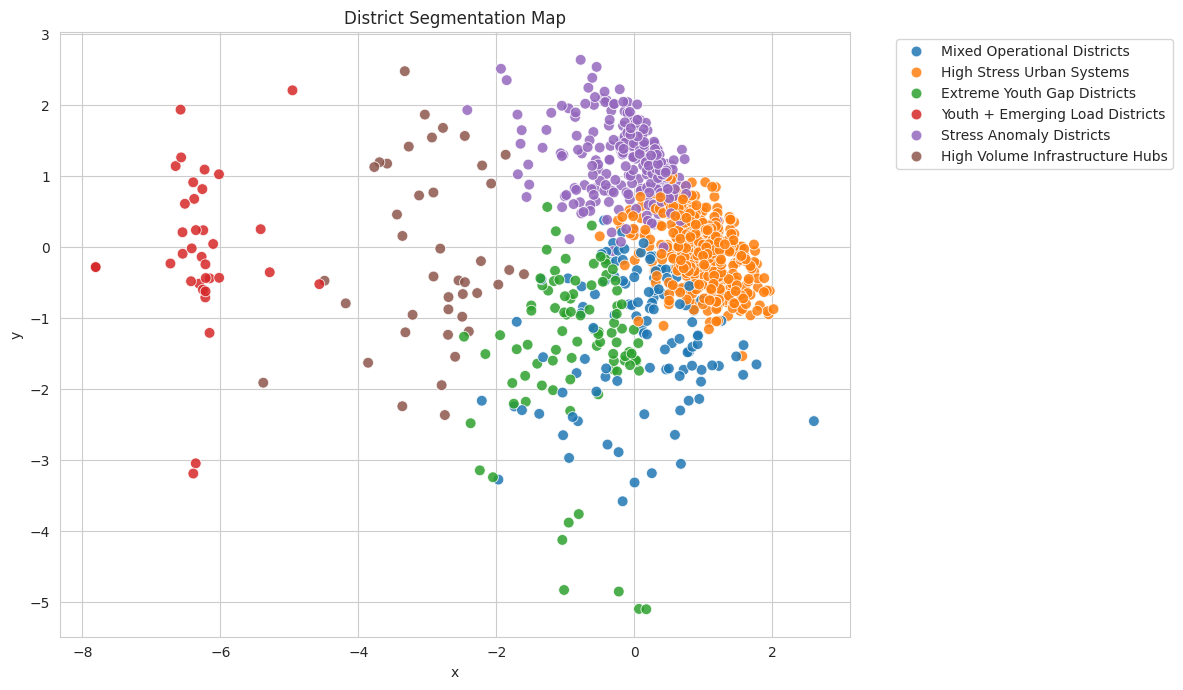

In [13]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=dist,
    x="x",
    y="y",
    hue="cluster_label",
    palette="tab10",
    s=60,
    alpha=0.85,
)
plt.title("District Segmentation Map")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Cluster feature profile heatmap

The heatmap shows the average value of each feature within each cluster.

How to read it:
- **warmer colors** indicate higher-than-average values,
- **cooler colors** indicate lower-than-average values.

This plot is the fastest way to understand why each cluster received its label.
For example:
- a cluster with high `youth_pct` and high `coverage_gap` is naturally an outreach opportunity cluster;
- a cluster with high `log_update_load` and high `log_bio_stress` is a service-pressure cluster.

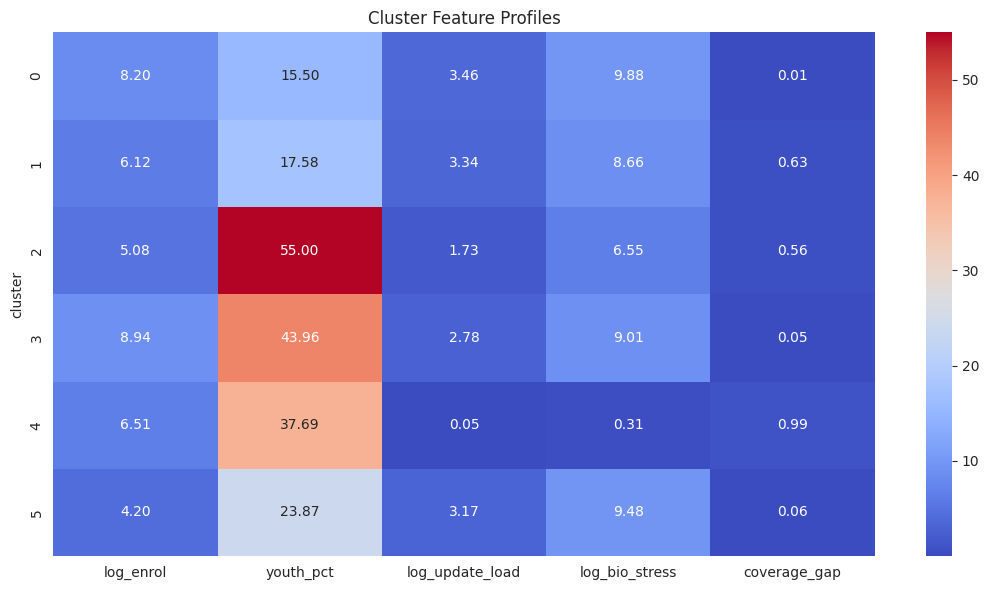

In [14]:
plt.figure(figsize=(11, 6))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cluster Feature Profiles")
plt.tight_layout()
plt.show()

## Distribution plots by cluster

Boxplots show the spread inside each cluster, not just the mean.

They are useful because they reveal:
- how concentrated a cluster is,
- whether the cluster contains outliers,
- and whether the label is describing a truly coherent group or only an average tendency.

If a cluster has a broad box, it is internally heterogeneous.
If the boxes are tight and separated, the cluster is operationally clean.

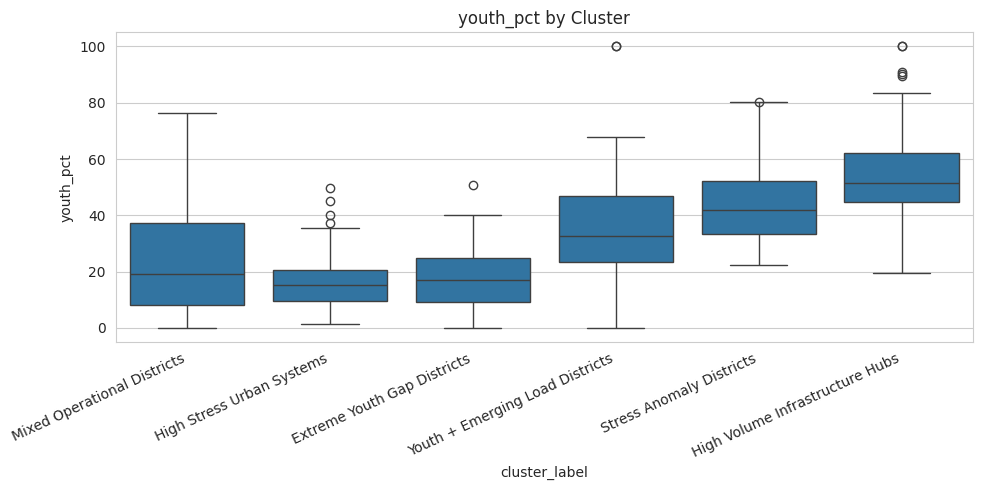

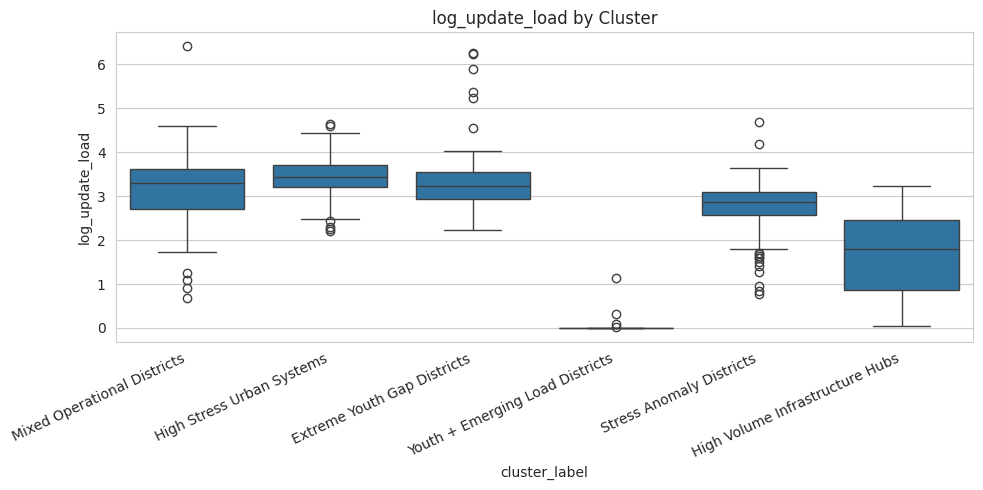

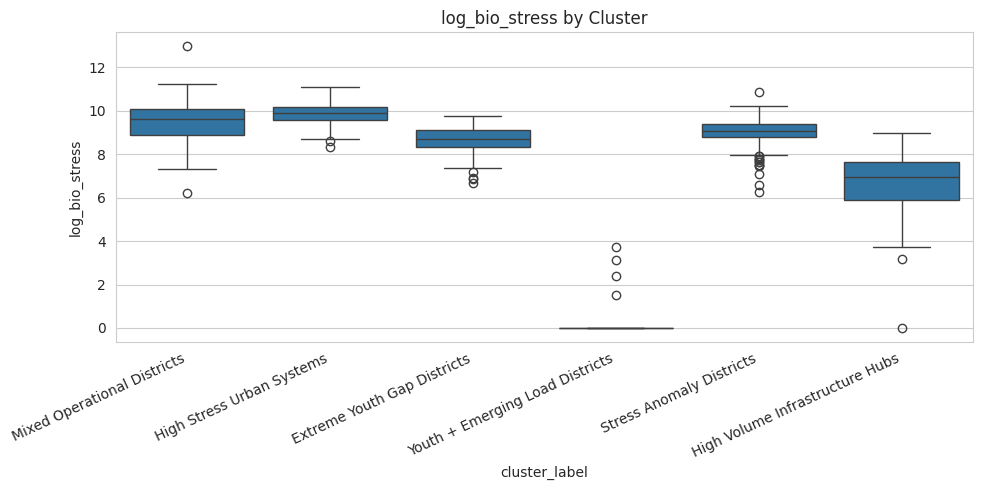

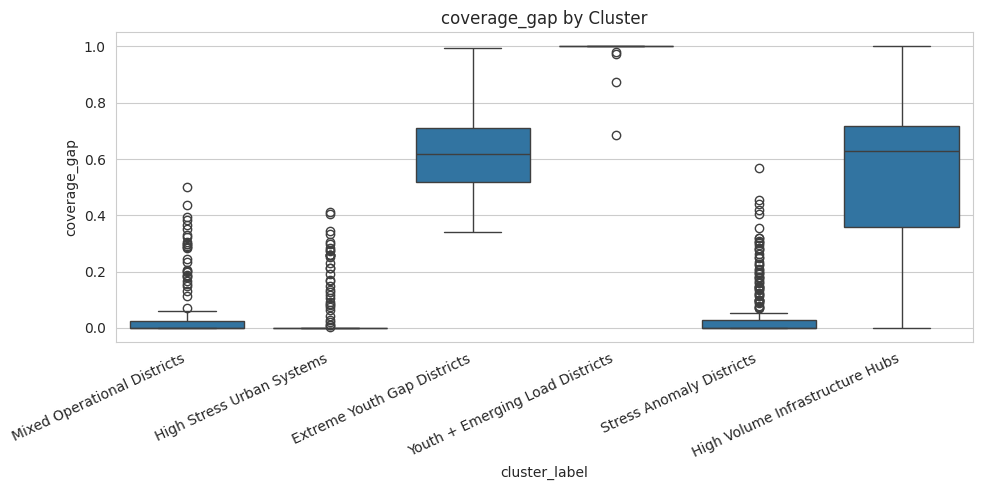

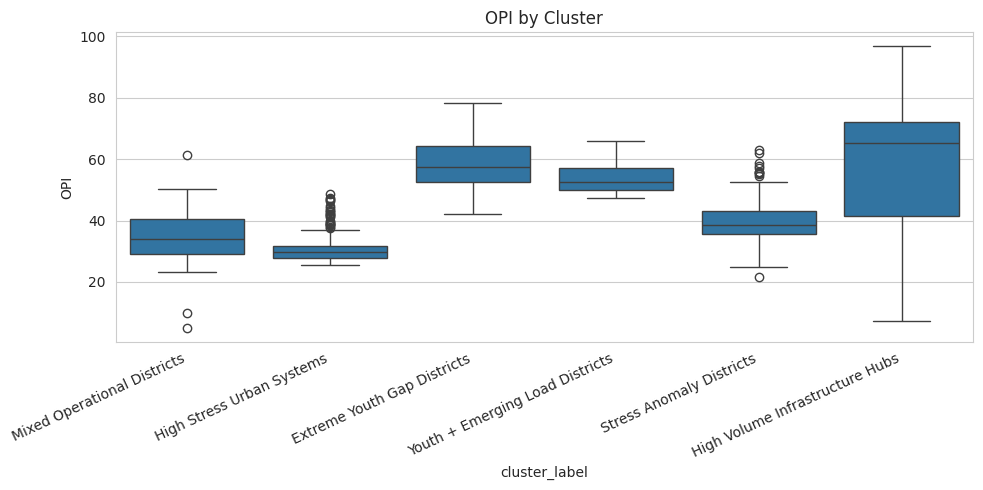

In [15]:
for f in ["youth_pct", "log_update_load", "log_bio_stress", "coverage_gap", "OPI"]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=dist, x="cluster_label", y=f)
    plt.xticks(rotation=25, ha="right")
    plt.title(f"{f} by Cluster")
    plt.tight_layout()
    plt.show()

## Tables for reporting and dashboard use

These tables are the most reusable outputs for the dashboard:

- **Cluster summary**: the one-line interpretation of each cluster.
- **Representative districts**: example districts nearest to each cluster centroid.
- **Top priority districts**: the districts with the highest OPI after excluding data-quality issues.
- **Top stress districts**: the districts with the highest biometric burden.

These are the tables you will cite in slides, report text, or dashboard tooltips.

In [16]:
# Representative districts per cluster: closest to centroid in PCA space
dist["_cluster_centroid_dist"] = np.nan
for c in sorted(dist[dist["cluster"] != -1]["cluster"].unique()):
    idx = dist["cluster"] == c
    centroid = final_model.cluster_centers_[int(c)] if hasattr(final_model, "cluster_centers_") else None
    if centroid is not None:
        dist.loc[idx, "_cluster_centroid_dist"] = np.linalg.norm(X_pca[idx.values] - centroid, axis=1)

representatives = (
    dist[dist["cluster"] != -1]
    .sort_values(["cluster", "_cluster_centroid_dist"], ascending=[True, True])
    .groupby("cluster")
    .head(5)[[
        "state_clean", "district", "cluster", "cluster_label", "cluster_signature",
        "OPI", "youth_pct", "update_load_capped", "bio_stress_capped", "coverage_gap"
    ]]
)

print("Cluster representatives:")
display(representatives)

print("Top priority districts (OPI, excluding data issues):")
display(top_priority_districts)

print("Top biometric stress districts:")
display(top_stress_districts)

Cluster representatives:


,state_clean,district,cluster,cluster_label,cluster_signature,OPI,youth_pct,update_load_capped,bio_stress_capped,coverage_gap
639,odisha,puri,0,High Stress Urban Systems,High Update Load + High Biometric Stress + Hig...,29.615385,15.384615,5.000000,2000.000000,0.000000
630,odisha,khorda,0,High Stress Urban Systems,High Update Load + High Biometric Stress + Hig...,29.551772,15.172574,5.000000,2000.000000,0.000000
626,odisha,kandhamal,0,High Stress Urban Systems,High Update Load + High Biometric Stress + Hig...,29.284323,14.281078,5.000000,2000.000000,0.000000
755,tamil nadu,sivaganga,0,High Stress Urban Systems,High Update Load + High Biometric Stress + Hig...,29.622132,15.407108,5.000000,2000.000000,0.000000
605,odisha,angul,0,High Stress Urban Systems,High Update Load + High Biometric Stress + Hig...,29.116279,13.720930,5.000000,2000.000000,0.000000
197,chhattisgarh,sakti,1,Extreme Youth Gap Districts,Very High Coverage Gap + High Youth + Low Upda...,56.577771,17.582418,5.000000,2000.000000,0.584512
976,west bengal,south dinajpur,1,Extreme Youth Gap Districts,Very High Coverage Gap + High Youth + Low Upda...,60.752468,15.919283,5.000000,2000.000000,0.688371
783,telangana,jayashankar bhupalpally,1,Extreme Youth Gap Districts,Very High Coverage Gap + High Youth + Low Upda...,63.486220,20.425030,5.000000,2000.000000,0.719082
789,telangana,komaram bheem,1,Extreme Youth Gap Districts,Very High Coverage Gap + High Youth + Low Upda...,59.267270,17.088608,5.000000,2000.000000,0.647571
782,telangana,jangoan,1,Extreme Youth Gap Districts,Very High Coverage Gap + High Youth + Low Upda...,54.434094,12.720157,5.000000,2000.000000,0.569290


Top priority districts (OPI, excluding data issues):


,state_clean,district,OPI,coverage_gap,youth_pct,update_load_capped,bio_stress_capped
557,manipur,pherzawl,96.761364,0.988636,90.909091,5.0,181.818182
373,karnataka,bengaluru south,95.275353,0.960689,90.147783,5.0,719.211823
110,assam,tamulpur district,85.515773,0.944795,60.000000,5.0,1272.727273
693,rajasthan,deeg,83.222211,0.878368,62.318841,5.0,2000.000000
974,west bengal,south 24 pargana,78.793103,0.862069,50.000000,5.0,1999.999999
189,chhattisgarh,manendragarh–chirmiri–bharatpur,78.343219,0.945042,36.054422,5.0,955.782313
723,sikkim,namchi,77.952128,0.982270,29.166667,5.0,208.333333
76,assam,bajali,77.049559,0.972749,27.586207,5.0,793.103448
120,bihar,bhabua,75.201613,0.750000,54.838710,5.0,1064.516129
56,arunachal pradesh,kamle,74.764151,0.550314,83.333333,5.0,2000.000000


Top biometric stress districts:


,state_clean,district,bio_stress_capped,update_load_capped,coverage_gap,OPI
980,west bengal,west midnapore,2000.0,5.0,0.381421,49.561211
0,andaman and nicobar islands,andamans,2000.0,5.0,0.000000,27.000000
1,andaman and nicobar islands,nicobar,2000.0,5.0,0.000000,29.400000
961,west bengal,medinipur,2000.0,5.0,0.578652,54.142774
960,west bengal,maldah,2000.0,5.0,0.371798,51.400627
959,west bengal,malda,2000.0,5.0,0.514633,55.657557
958,west bengal,kolkata,2000.0,5.0,0.145419,44.893604
957,west bengal,koch bihar,2000.0,5.0,0.814298,71.598606
955,west bengal,jhargram,2000.0,5.0,0.448057,50.495220
954,west bengal,jalpaiguri,2000.0,5.0,0.569929,63.154794


## Saving dashboard-ready artifacts

The final step is to save the derived tables that power the dashboard and the report.

Each file has a distinct role:
- some are audit files,
- some are model selection files,
- some are cluster interpretation files,
- and some are ranking tables.

The notebook saves not just the final answer, but also the evidence trail that explains how the final answer was reached.

In [17]:
OUT = Path("/kaggle/working")
OUT.mkdir(parents=True, exist_ok=True)

# Core dashboard tables
dist.to_csv(OUT / "uidai_district_model_table.csv", index=False)

state_summary = dist.groupby("state_clean").agg(
    district_count=("district", "nunique"),
    total_enrolments=("total_enrolments", "sum"),
    youth_pct=("youth_pct", "mean"),
    update_load=("update_load", "mean"),
    bio_stress=("bio_stress", "mean"),
    coverage_gap=("coverage_gap", "mean"),
    OPI_mean=("OPI", "mean"),
    data_issue_count=("data_issue", "sum"),
).reset_index()
state_summary.to_csv(OUT / "uidai_state_summary.csv", index=False)

compare_df.to_csv(OUT / "uidai_clustering_model_comparison.csv", index=False)
cluster_profile.to_csv(OUT / "uidai_cluster_profile.csv")
cluster_summary.to_csv(OUT / "uidai_cluster_summary.csv")
representatives.to_csv(OUT / "uidai_cluster_representatives.csv", index=False)
top_priority_districts.to_csv(OUT / "uidai_top_priority_districts.csv", index=False)
top_stress_districts.to_csv(OUT / "uidai_top_stress_districts.csv", index=False)

# Audit / refinement files
state_variant_report.to_csv(OUT / "uidai_state_variant_audit.csv", index=False)
district_variant_report.to_csv(OUT / "uidai_district_variant_audit.csv", index=False)
dist[dist["data_issue"]].to_csv(OUT / "uidai_data_issue_districts.csv", index=False)

# Dashboard manifest
manifest = {
    "uidai_district_model_table.csv": {
        "purpose": "Main district-level feature table",
        "use_in_dashboard": "Primary filterable table and drill-down source",
        "contains": ["district features", "OPI", "cluster labels", "data_issue"],
    },
    "uidai_state_summary.csv": {
        "purpose": "State-level summary table",
        "use_in_dashboard": "Top-level state cards and state comparison view",
        "contains": ["district_count", "total_enrolments", "average OPI", "average coverage_gap"],
    },
    "uidai_clustering_model_comparison.csv": {
        "purpose": "Model selection audit",
        "use_in_dashboard": "Explain why the final clustering model was chosen",
        "contains": ["silhouette", "Davies–Bouldin", "cluster balance", "final score"],
    },
    "uidai_cluster_profile.csv": {
        "purpose": "Average feature profile per cluster",
        "use_in_dashboard": "Heatmap and cluster interpretation panel",
        "contains": ["cluster means across features"],
    },
    "uidai_cluster_summary.csv": {
        "purpose": "Human-readable cluster labels and signatures",
        "use_in_dashboard": "Cluster cards, report narrative, tooltips",
        "contains": ["label", "signature", "size", "top drivers"],
    },
    "uidai_cluster_representatives.csv": {
        "purpose": "Representative districts per cluster",
        "use_in_dashboard": "Example districts under each archetype",
        "contains": ["nearest-to-centroid districts"],
    },
    "uidai_top_priority_districts.csv": {
        "purpose": "Priority ranking table",
        "use_in_dashboard": "Action queue for outreach and deployment",
        "contains": ["highest OPI districts excluding data issues"],
    },
    "uidai_top_stress_districts.csv": {
        "purpose": "Biometric stress ranking table",
        "use_in_dashboard": "Equipment refresh / stress monitoring queue",
        "contains": ["highest biometric stress districts"],
    },
    "uidai_state_variant_audit.csv": {
        "purpose": "State cleaning audit",
        "use_in_dashboard": "Internal QA / refinement evidence",
        "contains": ["state spellings that were normalized"],
    },
    "uidai_district_variant_audit.csv": {
        "purpose": "District cleaning audit",
        "use_in_dashboard": "Internal QA / refinement evidence",
        "contains": ["district spellings and aliases"],
    },
    "uidai_data_issue_districts.csv": {
        "purpose": "Districts excluded from priority ranking",
        "use_in_dashboard": "Data-quality review / transparency panel",
        "contains": ["districts with missing join signals"],
    },
}

with open(OUT / "uidai_dashboard_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("Saved files to:", OUT)
print("\nFiles:")
for fn in sorted([p.name for p in OUT.glob("uidai_*")]):
    print(" -", fn)

Saved files to: /kaggle/working

Files:
 - uidai_cluster_profile.csv
 - uidai_cluster_representatives.csv
 - uidai_cluster_summary.csv
 - uidai_clustering_model_comparison.csv
 - uidai_dashboard_manifest.json
 - uidai_data_issue_districts.csv
 - uidai_district_model_table.csv
 - uidai_district_variant_audit.csv
 - uidai_state_summary.csv
 - uidai_state_variant_audit.csv
 - uidai_top_priority_districts.csv
 - uidai_top_stress_districts.csv


## Final summary

By the end of the notebook, we have:

- a strict, transparent cleaning pipeline,
- a district-level feature table,
- an OPI that excludes data-quality issues from the ranked list,
- a model-comparison audit,
- a final six-cluster operational segmentation,
- and a complete set of dashboard-ready CSVs.

This is the final bridge from raw data to a decision-support product.